<img src="https://userweb.fct.unl.pt/~jmc.xavier/MSII/iLogos/logo_novafct.png" width="200">

# Departamento de Engenharia Mecânica e Industrial
## Mecânica dos Sólidos II

## Tensões principais

### Problema 2

Considere a viga representada na figura. No ponto A está aplicada uma força $P=$ 10 kN, oblíqua em relação ao referencial de eixos $xyz$ indicado. O ângulo que a força faz com os três eixos é respetivamente 45 $^\circ$, 60 $^\circ$, 120 $^\circ$. Determine:

**a)** A distribuição de tensões normais na secção BCDE, com a posição do eixo neutro e os valores máximo e mínimo da tensão $\sigma_{xx}$.

**b)** As tensões principais e a tensão tangencial máxima no ponto F.

<img src="https://userweb.fct.unl.pt/~jmc.xavier/MSII/Notebooks/Au07/P2/MSII_Au07_P2.png"
width="500">


## Resolução

#### **a)** A distribuição de tensões normais na secção BCDE, com a posição do eixo neutro e os valores máximo e mínimo da tensão $\sigma_{xx}$.

In [1]:
import numpy as np
import sympy as sy
from sympy.solvers import solve
import matplotlib.pyplot as plt
import os

cor = '2'
if cor == '1':
    plt.rcParams['axes.facecolor'] = (.15, .15, .15)
    plt.rcParams['figure.facecolor'] = (.15, .15, .15)
    plt.rcParams['font.family'] = 'monospace'
    plt.rcParams['font.size'] = 18
    # plt.rcParams['text.usetex'] = True
    params = {"ytick.color" : (.8, .8, .8),
              "xtick.color" : (.8, .8, .8),
              "grid.color" : (.2, .2, .2),
              "text.color" : (.7, .7, .7),
              "axes.labelcolor" : (.8, .8, .8),
              "axes.edgecolor" : (.15, .15, .15)}
else:
    plt.rcParams['axes.facecolor'] = (.7, .7, .7)
    plt.rcParams['figure.facecolor'] = (.7, .7, .7)
    plt.rcParams['font.family'] = 'monospace'
    plt.rcParams['font.size'] = 18
    # plt.rcParams['text.usetex'] = True
    params = {"ytick.color" : (.1, .1, .1),
              "xtick.color" : (.1, .1, .1),
              "grid.color" : (.2, .2, .2),
              "text.color" : (.1, .1, .1),
              "axes.labelcolor" : (.1, .1, .1),
              "axes.edgecolor" : (.15, .15, .15)}
plt.rcParams.update(params)

# data structure, units: N, mm, MPa

class varin: pass

d = varin()

d.tub_b = 80.*1e-3  # unit: m
d.tub_h = 50.*1e-3 # unit: m
d.tub_e = 6.*1e-3 # unit: m
d.xL = 100.e-3 # unit: m
d.zF = 20.e-3 # unit: m
d.P = 10.*1e3 # unit: N/m
d.alpha = 45. # unit: deg
d.beta = 60. # unit: deg
d.gamma = 120. # unit: deg

### Componentes cartesianas da Força $P$

\begin{equation*}
\begin{aligned}
\vec{P} &= P \vec{\lambda}
\quad\wedge\quad
\vec{\lambda} = \cos\alpha \,\vec{\imath} + \cos\beta \,\vec{\jmath}
+ \cos\gamma \,\vec{k} \\
\vec{P} &=  P \cos\alpha \,\vec{\imath} + P \cos\beta \,\vec{\jmath}
+ P \cos\gamma \,\vec{k}
\end{aligned}
\end{equation*}

In [2]:
Px = d.P*np.cos(np.deg2rad(d.alpha))
print(f'Px = {Px:.2f} [N]')
Py = d.P*np.cos(np.deg2rad(d.beta))
print(f'Py = {Py:.2f} [N]')
Pz = d.P*np.cos(np.deg2rad(d.gamma))
print(f'Pz = {Pz:.2f} [N]')

Px = 7071.07 [N]
Py = 5000.00 [N]
Pz = -5000.00 [N]


#### Sistema força-binário equivalente - via método das secções

- Diagrama de corpo livre ($N,V_z,V_z,M_x,M_y,M_z$)

Considere-se um troço da viga, seccionada a uma distância de 100 mm do bordo livre onde a força externa é aplicada. Nessa secção interna, exposta pelo corte, surgem forças distribuídas que equilibram o carregamento excêntrico externo aplicado. O carregamento externo pode ser substituído por um sistema força-binário ($N,V_z,V_z,M_x,M_y,M_z$) aplicado no centroide da secção e ao longo do sistema de eixos principais de inércia.

- Esforço axial, $N$

\begin{equation*}
N = P_x
\end{equation*}

In [3]:
N = Px
print(f'N = {N:.1f} [N]')

N = 7071.1 [N]


- Esforço transverso na direção $y$, $V_y$

\begin{equation*}
V_y = P_y
\end{equation*}

In [ ]:
Vy = Py
print(f'Vy = {Vy:.1f} [N]')

In [ ]:

\begin{equation*}
V_z = -P_z = P_z\downarrow 
\end{equation*}

In [5]:
Vz = Pz
print(f'Vz = {Vz:.1f} [N]')

Vz = -5000.0 [N]


- Momento torsor em torno do eixo $x$, $M_x(\equiv T)$

Avaliando o momento de torção causado pelas forças que atuam no plano perpendicular ao eixo dos $x$:

\begin{equation*}
M_x = P_y \cdot b/2 - P_z\cdot h/2
\end{equation*}

com: 

- $\vec{r}_{\vec{P_y}} = -h/2~\vec{k} ~\wedge~ \vec{P}_y = P_y~\vec{\jmath} \quad\therefore\quad P_y (h/2)~\vec{\imath}$
 
- $\vec{r}_{\vec{P_z}} = b/2~\vec{\jmath} ~\wedge~ \vec{P}_z = -P_z~\vec{k} \quad\therefore\quad -P_z (b/2)~\vec{\imath}$

In [17]:
Mx = Py*d.tub_b/2 - np.abs(Pz)*d.tub_h/2
print(f'Mx = {Py:.1f}({d.tub_b/2}) - {np.abs(Pz):.1f}({d.tub_h/2}) = {Mx:.1f} [N.m]')

Mx = 5000.0(0.04) - 5000.0(0.025) = 75.0 [N.m]


- Momento fletor em torno do eixo $y$, $M_y$

Por definição de momento de uma força, só exercem momento de flexão em relação ao eixo $y$, as forças que são coplanares com o plano $x-z$ que lhe é perpendicular. Neste caso, ambas as forças $P_x$ e $P_z$ contribuem para $M_y$:

\begin{equation*}
M_y = - P_x \cdot b/2 + P_z \cdot x_L
\end{equation*}

com

- $\vec{r}_{\vec{P_z}} = x_L~\vec{\imath} ~\wedge~ \vec{P}_z = -P_z~\vec{k}  \quad\therefore\quad P_z x_L~\vec{\jmath}$
- $\vec{r}_{\vec{P_x}} = -b/2~\vec{k} ~\wedge~ \vec{P}_x = P_x~\vec{\imath} \quad\therefore\quad -P_x (b/2)~\vec{\jmath}$

In [7]:
My = -Px*d.tub_b/2 + np.abs(Pz)*d.xL
print(f'My = -{Px:.1f}({d.tub_b/2}) + {np.abs(Pz):.1f}({d.xL}) = {My:.1f} [N.m]')

My = -7071.1(0.04) + 5000.0(0.1) = 217.2 [N.m]


- Momento fletor em torno do eixo $z$, $M_z$

As forças de exercem momento em relação ao eixo $z$ são as forças contidas no plano $x-y$, $P_x$, $P_y$:

\begin{equation*}
 M_z = - P_x \cdot h/2 + P_y x_L
\end{equation*}

com

- $\vec{r}_{\vec{P_x}} = h/2~\vec{\jmath} ~\wedge~ \vec{P}_x = P_x~\vec{\imath} \quad\therefore\quad - P_x (h/2)~\vec{k}$
- $\vec{r}_{\vec{P_y}} = x_L~\vec{\imath} ~\wedge~ \vec{P}_y = P_y~\vec{\imath} \quad\therefore\quad P_2 (h/2)~\vec{k}$

In [8]:
Mz = -Px*d.tub_h/2 + Py*d.xL
print(f'Mz = -{Px:.1f}({d.tub_h/2}) + {Py:.1f}({d.xL}) = {Mz:.1f} [N.m]')

Mz = -7071.1(0.025) + 5000.0(0.1) = 323.2 [N.m]


Depois da análise do equilíbrio de forças estático, determinem-se as propriedades de área da secção:

- Área da secção

In [9]:
A = d.tub_b*d.tub_h - (d.tub_b-2*d.tub_e)*(d.tub_h-2*d.tub_e)
print(f'A = {d.tub_b:.3f}x{d.tub_h:.3f} - {d.tub_b-2*d.tub_e:.3f}x{d.tub_h-2*d.tub_e:.3f} = {A:.3e} [m^2]')

A = 0.080x0.050 - 0.068x0.038 = 1.416e-03 [m^2]


- Momento de inércia em relação ao eixo $z$, $I_z$

Nota: na expressão $I_i = bh³/12$, a dimensão ao cubo ($h³$) é sempre uma dimensão perpendicular ao eixo em análise $i$.

In [10]:
def irect(b,h): return b*h**3/12

Iz1 = irect(d.tub_b,d.tub_h)
Iz2 = irect(d.tub_b-2*d.tub_e,d.tub_h-2*d.tub_e)
Iz = Iz1 - Iz2
print(f'Iz = {Iz1:.3e} - {Iz2:.3e} = {Iz:.3e} [m^4]')

Iz = 8.333e-07 - 3.109e-07 = 5.224e-07 [m^4]


- Momento de inércia em relação ao eixo $y$, $I_y$

In [11]:
Iy1 = irect(d.tub_h,d.tub_b)
Iy2 = irect(d.tub_h-2*d.tub_e,d.tub_b-2*d.tub_e)
Iy = Iy1 - Iy2
print(f'Iy = {Iy1:.3e} - {Iy2:.3e} = {Iy:.3e} [m^2]')

Iy = 2.133e-06 - 9.957e-07 = 1.138e-06 [m^2]


#### Esforço combinado

Neste cenário de carregamento excêntrico, pelo princípio de Saint-Venant, as tensões normais numa secção suficientemente afastada das extremidades da barra (devido a efeito de concentração de tensões) podem ser calculadas, atendendo ainda ao princípio da sobreposição, por:

\begin{equation*}
\sigma_{xx} = \frac{N}{A} - \frac{M_z}{I_z}y + \frac{M_y}{I_y} z
\end{equation*}

De notar que os sinais efetivos desta expressão são função dos sinais de $N$, $M_z$ e $M_y$ do problema em análise.

Eq = sigx + 618737087.672405*y - 190885354.42514*z - 4993691.95753212
sigxx(y,z)  = -618.737087672405*y + 190.88535442514*z + 4.99369195753212 [MPa]
y = 0.308508020980643*z + 0.00807078168906543 (recta geométrica do eixo neutro) [m]
z = 3.24140680952585*y - 0.0261606867251333 (recta geométrica do eixo neutro) [m]


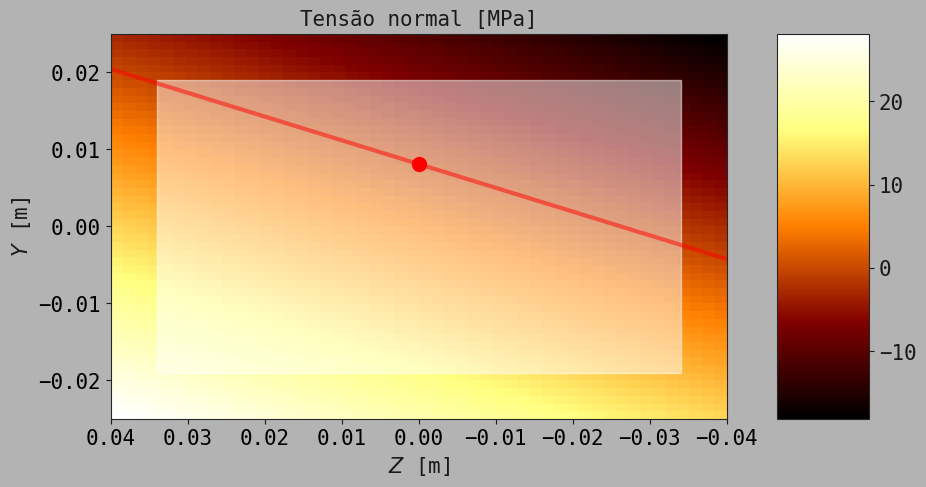

In [12]:
from mpl_toolkits.axes_grid1 import make_axes_locatable
from matplotlib.patches import Rectangle

y, z, sigx = sy.symbols('y z sigx')

Eq = sigx - N/A + Mz/Iz*y - My/Iy*z
print(f'Eq = {Eq}')
sigxx = solve(Eq,sigx)[0]
print(f'sigxx(y,z)  = {sigxx*1e-6} [MPa]')

zsiz = np.linspace(d.tub_b/2,-d.tub_b/2)
ysiz = np.linspace(d.tub_h/2,-d.tub_h/2)
Z, Y = np.meshgrid(zsiz, ysiz)

def tensnormal(y2,z2):
    return sigxx.subs({(y,y2),(z,z2)}) #- eval_NAB/A - eval_MzAB/Iz*y + eval_MyAB/Iy*z

SxxMap = np.zeros(np.shape(Z))
for i in range(0,len(ysiz)):
    for j in range(0,len(zsiz)):
        SxxMap[i,j] = tensnormal(ysiz[i],zsiz[j])

yzfun = solve(sigxx,y)[0]
print(f'y = {yzfun} (recta geométrica do eixo neutro) [m]')
print(f'z = {solve(sigxx,z)[0]} (recta geométrica do eixo neutro) [m]')

zplo = zsiz
yplo = np.zeros(len(zplo))
for i in range(0,len(zplo)):
    yplo[i] = yzfun.subs(z,zplo[i])

fzp = 15
# Visualizacao u1(X1,X2,X3,t1)
fig = plt.figure(figsize=(10, 5))
ax  = plt.gca()
ttl = plt.title('Tensão normal [MPa]',fontsize=15)
ttl.set_position([0.5, 1.05])
plt.ylabel(r'$Y$ [m]',fontsize=fzp)
plt.xlabel(r'$Z$ [m]',fontsize=fzp)
im = ax.imshow(SxxMap*1e-6, extent=[d.tub_b/2, -d.tub_b/2, -d.tub_h/2,d.tub_h/2], cmap="afmhot")
ax.add_patch(Rectangle((-d.tub_b/2+d.tub_e, -d.tub_h/2+d.tub_e), d.tub_b-2*d.tub_e, d.tub_h-2*d.tub_e,color="white",alpha=0.5))
plt.plot(zplo,yplo,'r-',linewidth=3,alpha=0.5)
ax.plot(0,yzfun.subs(z,0),'or',markersize=10)
plt.xticks(color ='k', size=fzp)
plt.yticks(color ='k', size=fzp)
divider = make_axes_locatable(ax)
cax = divider.append_axes("right", size="15%", pad=0.5)
cbar = plt.colorbar(im, cax=cax, orientation = "vertical")
cbar.ax.tick_params(labelsize=fzp)
plt.show()

In [13]:
ymax_, zmax_ = d.tub_h/2, -d.tub_b/2
sigmax_ = tensnormal(ymax_,zmax_)
print(f'sig.max :: ({ymax_},{zmax_}) :: {sigmax_*1e-6:.2f} [MPa]')

ymin_, zmin_ = -d.tub_h/2, d.tub_b/2
sigmin_ = tensnormal(ymin_,zmin_)
print(f'sig.min :: ({ymin_},{zmin_}) :: {sigmin_*1e-6:.2f} [MPa]')

sig.max :: (0.025,-0.04) :: -18.11 [MPa]
sig.min :: (-0.025,0.04) :: 28.10 [MPa]


#### **b)** As tensões principais e a tensão tangencial máxima no ponto F.

In [14]:
yF, zF = d.tub_h/2, d.tub_b/2-d.zF
sigF = tensnormal(yF, zF)
print(f'sig.F :: ({yF},{zF}) :: {sigF*1e-6:.3f} [MPa]')

sig.F :: (0.025,0.02) :: -6.657 [MPa]


- Tensor das tensões num ponto material:

\begin{equation*}
[\sigma] =
\begin{bmatrix}
\sigma_{xx} & \tau_{xy} & \tau_{xz} \\
\tau_{xy} & \sigma_{yy} & \tau_{yz} \\
\tau_{xz} & \tau_{yz} & \sigma_{zz}
\end{bmatrix}
\end{equation*}

No problema de flexão em estudo apenas existem tensões normais segundo a direção $x~:~\sigma_{xx}=N/A~,~\sigma_{yy}=\sigma_{zz}=0$. Por outro lado, ponto F está situado na parede superior do perfil pelo que $\tau_{xy} = \tau_{yz}= 0$, resultando:

\begin{equation*}
[\sigma] =
\begin{bmatrix}
\sigma_{xx} & 0 & \tau_{xz} \\
0 & 0 & 0 \\
\tau_{xz} & 0 & 0
\end{bmatrix}
\end{equation*}

Determinação das componentes de tensão de corte, $\tau_{xz}$, no ponto F: $\quad T (\equiv M_x), V_y, V_z ~\longrightarrow~ \tau_{xz}$

- Análise da tensão de corte $\tau_{xz}$ devida à torção $T (\equiv M_x)$:

A tensão de corte média resultante do momento torsor é dada por:

\begin{equation*}
\tau_{xz}^{(T)} = \frac{|T|}{2A_0t}
\end{equation*}

onde, $A_0$ é a área interna definida pelo contorno da linha central da parede do perfil e $t$ é a espessura da parede do perfil tubular.

In [15]:
tor_A0 = (d.tub_h-d.tub_e)*(d.tub_b-d.tub_e)
print(f'tor_A0 = {tor_A0:.3e} [m²]')
tor_t = d.tub_e
print(f'tor_t = {tor_t:.3f} [m]')
tauxz_T = Mx/2/tor_A0/tor_t
print(f'>>>> T = {Mx:.1f} [N] :: tauxy_T = {tauxz_T*1e-6:.3f} [MPa]')

tor_A0 = 3.256e-03 [m²]
tor_t = 0.006 [m]
>>>> T = 75.0 [N] :: tauxy_T = 1.920 [MPa]


- Análise da tensão de corte $\tau_{xz}$ devida ao esforço transverso $V_y$:

Recorrendo ao formulário da expressão da tensão de corte em relação ao esforço transverso (de notar que nesta expressão o valor de $V$ é considerado sempre positivo, conforme a convenção de sinais):

\begin{equation*}
\tau_{xz}^{(V_y)} = \left| \frac{V_y Q_z}{I_zt} \right|
\quad\wedge\quad Q_z = \int_A^* y\,\mathrm{d}A = A^*\overline{y} = \sum_i A_i^*\overline{y}_i
\end{equation*}

<img src="https://userweb.fct.unl.pt/~jmc.xavier/MSII/Notebooks/Au07/P2/MSII_Au07_P2a.png"
width="500">

In [16]:
print('area a vermelho:')
A_ = d.zF*d.tub_e
print(f'A = {Az_:.3e} [m³]')
y_ = d.tub_h/2 - d.tub_e/2
print(f'y = {y_:.3e} [m³]')
Qz = A_*y_
print(f'Qz = {Qz:.3e} [m³]')
tauxy_Vy = -np.abs(Vy*Qz)/Iz/d.tub_e # o sinal negativo vem pela convenção de sinal para tau_xz
print(f'::\nVy = {Vy:.3f} [N]')
print(f'Qz = {Qz:.3e} [m³]')
print(f'Iz = {Iz:.3e} [m⁴]')
print(f't  = {d.tub_e:.3e} [m]')
print(f'>>> Vy = {np.abs(Vy):.1f} [N] :: tauxy_Vy  = {tauxy_Vy *1e-6:.3f} ← [MPa]')

area a vermelho:


NameError: name 'Az_' is not defined

In [63]:
print('area desde o ponto de entrada (Qz = 0) até ao ponto F:')
A1_ = (d.tub_b/2 - d.zF)*d.tub_e
y1_ = d.tub_h/2 - d.tub_e/2
A2_ = (d.tub_h/2 - 2*d.tub_e)*d.tub_e
y2_ = 0
A3_ = d.tub_b/2*d.tub_e
y3_ = -(d.tub_h/2 - d.tub_e/2)
Qz_v2 = A1_*y1_ + A2_*y2_ + A3_*y3_
print(f'Qz_v2 = {Qz_v2:.3e} [m³]')
tauxy_Vy_v2 = -np.abs(Vy*Qz_v2)/Iz/d.tub_e # o sinal negativo vem pela convenção de sinal para tau_xz
print(f'::\nVy = {Vy:.3f} [N]')
print(f'|Qz| = {np.abs(Qz_v2):.3e} [m³]')
print(f'Iz = {Iz:.3e} [m⁴]')
print(f't  = {d.tub_e:.3e} [m]')
print(f'>>> Vy = {np.abs(Vy):.1f} [N] :: tauxy_Vy  = {tauxy_Vy_v2 *1e-6:.3f} ← [MPa]')

area desde o ponto de entrada (Qz = 0) até ao ponto F:
Qz_v2 = -2.640e-06 [m³]
::
Vy = 5000.000 [N]
|Qz| = 2.640e-06 [m³]
Iz = 5.224e-07 [m⁴]
t  = 6.000e-03 [m]
>>> Vy = 5000.0 [N] :: tauxy_Vy  = -4.211 ← [MPa]


- Análise da tensão de corte $\tau_{xz}$ devida ao esforço transverso $V_z$:

\begin{equation*}
\tau_{xy}^{(Vz)} = \left| \frac{V_zQ_y}{I_yt} \right|
\quad\wedge\quad Q_y = \int_A^* z\,\mathrm{d}A = A^*\overline{z} = \sum_i A_i^*\overline{z}_i
\end{equation*}

<img src="https://userweb.fct.unl.pt/~jmc.xavier/MSII/Notebooks/Au07/P2/MSII_Au07_P2b.png"
width="500">

In [60]:
yretmaior = d.tub_b/2-(d.tub_b/2-d.zF)/2
print(f'---\nyM_ = {yretmaior:.3f} [m]')
Aretmaior = d.tub_h*(d.tub_b/2-d.zF)
print(f'AM_ = {d.tub_h:.3f} x {d.tub_b/2-d.zF:.3f} = {Aretmaior:.3e} [m²]')
Qretmaior = Aretmaior*yretmaior
print(f'QM_ = {Qretmaior:.3e} [m³]')
yretmenor = (d.tub_b/2-d.tub_e-d.zF)/2+d.zF
print(f'---\nym__ = {yretmenor:.3f} [m]')
Aretmenor = (d.tub_b/2-d.tub_e-d.zF)*(d.tub_h-2*d.tub_e)
print(f'Am_ = {d.tub_b/2-d.tub_e-d.zF:.3f} x {d.tub_h-2*d.tub_e:.3f} = {Aretmenor:.3e} [m²]')
Qretmenor = Aretmenor*yretmenor
print(f'Qm_ = {Qretmenor:.3e} [m³]')
Qy = Qretmaior - Qretmenor
print(f'---\nQz = QM_ - Qm_ = {Qretmaior:.3e} - {Qretmenor:.3e} = {Qy:.3e} [m³]')
tauxz_Vz = -np.abs(Vz)*Qy/Iy/(2*d.tub_e) # o sinal negativo vem pela convenção de sinal para tau_xz
print(f'::\nVy = {Vy:.3f} [N]')
print(f'Qy = {Qy:.3e} [m³]')
print(f'Iy = {Iy:.3e} [m⁴]')
print(f'2*t  = {2*d.tub_e:.3e} [m]')
print(f'>>> Vy = {np.abs(Vz):.1f} [N] ::  tauxz_Vz = {tauxz_Vz*1e-6:.3f} ← [MPa]')

---
yM_ = 0.030 [m]
AM_ = 0.050 x 0.020 = 1.000e-03 [m²]
QM_ = 3.000e-05 [m³]
---
ym__ = 0.027 [m]
Am_ = 0.014 x 0.038 = 5.320e-04 [m²]
Qm_ = 1.436e-05 [m³]
---
Qz = QM_ - Qm_ = 3.000e-05 - 1.436e-05 = 1.564e-05 [m³]
::
Vy = 5000.000 [N]
Qy = 1.564e-05 [m³]
Iy = 1.138e-06 [m⁴]
2*t  = 1.200e-02 [m]
>>> Vy = 5000.0 [N] ::  tauxz_Vz = -5.727 ← [MPa]


- Tensor das tensões no ponto F, $[\sigma_F]$:

\begin{equation*}
\sigma_{xx}(y_F,z_F)
~\wedge~ \tau_{xy} = 0
~\wedge~ \tau_{xz} = \frac{T}{2A_0t} - \frac{V_yQ_z}{I_zt} - \frac{V_zQ_y}{I_yt}
\end{equation*}

Pelo que o tensor das tensões vem:

\begin{equation*}
[\sigma_E] =
\begin{bmatrix}
\sigma_{xx}(y_E,z_E) & 0 & \left(\displaystyle\frac{T}{2A_0t} - \frac{V_yQ_z}{I_zt} - \frac{V_zQ_y}{I_yt}\right) \\
0 & 0 & 0 \\
\left(\displaystyle\frac{T}{2A_0t} - \frac{V_yQ_z}{I_zt} - \frac{V_zQ_y}{I_yt}\right) & 0 & 0
\end{bmatrix}
\quad\textrm{[MPa]}
\end{equation*}

In [61]:
np.set_printoptions(precision=4)

def tenstens(s11,s12,s13,s22,s23,s33):
    return np.array([[s11,s12,s13],[s12,s22,s23],[s13,s13,s33]], np.float64)

print(f'tau_xz = {tauxz_T*1e-6:.1f}+({tauxy_Vy*1e-6:.1f})+({tauxz_Vz*1e-6:.1f}) [MPa]')

ttE = tenstens(sigF,0,tauxz_T+tauxy_Vy+tauxz_Vz,0,0,0)
print(f"ttE :: \n {np.array2string(ttE*1e-6, precision=2, floatmode='fixed')} [MPa]")

tau_xz = 1.9+(-4.2)+(-5.7) [MPa]
ttE :: 
 [[-6.66  0.00 -8.02]
 [ 0.00  0.00  0.00]
 [-8.02 -8.02  0.00]] [MPa]


---

Copyright (c) DEMI - FCT NOVA

Interactive computing by <a href="https://jupyter.org/" target="_blank"> <span
style="color:#333399"> Jupyter Notebook </span> </a> &nbsp;|&nbsp;Coded by <a href = "mailto: jmc.xavier@fct.unl.pt">José Xavier</a>

Licensed under  <a href="http://creativecommons.org/licenses/by-sa/4.0/"
target="_blank"> <span style="color:#333399;font-size: 20px"> CC BY-SA 4.0  </span></a>